# Seaborn Intro

In [1]:
# Import Libraries
from datasets import load_dataset
import ast 
import pandas as pd
import matplotlib.pyplot as plt

# Load Dataset
raw = load_dataset('lukebarousse/data_jobs')
data = raw['train'].to_pandas()
df = data.copy()

# Data cleaning
df['job_posted_date'] = pd.to_datetime(df.job_posted_date)
df['job_skills'] = df['job_skills'].apply(lambda x : ast.literal_eval(x) if pd.notna(x) else x)

In [2]:
import seaborn as sns

**Example 1**

In [5]:
df_us = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')]
df_us=df_us.dropna(subset='salary_year_avg')
df_us =df_us.explode('job_skills')
df_us

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
109,Data Analyst,Senior Supply Chain Analytics Analyst,Anywhere,via Get.It,Full-time,True,"Illinois, United States",2023-10-12 13:02:19,False,True,United States,year,89000.0,NaN,Get It Recruit - Transportation,python,"{'analyst_tools': ['alteryx', 'tableau'], 'pro..."
109,Data Analyst,Senior Supply Chain Analytics Analyst,Anywhere,via Get.It,Full-time,True,"Illinois, United States",2023-10-12 13:02:19,False,True,United States,year,89000.0,NaN,Get It Recruit - Transportation,r,"{'analyst_tools': ['alteryx', 'tableau'], 'pro..."
109,Data Analyst,Senior Supply Chain Analytics Analyst,Anywhere,via Get.It,Full-time,True,"Illinois, United States",2023-10-12 13:02:19,False,True,United States,year,89000.0,NaN,Get It Recruit - Transportation,alteryx,"{'analyst_tools': ['alteryx', 'tableau'], 'pro..."
109,Data Analyst,Senior Supply Chain Analytics Analyst,Anywhere,via Get.It,Full-time,True,"Illinois, United States",2023-10-12 13:02:19,False,True,United States,year,89000.0,NaN,Get It Recruit - Transportation,tableau,"{'analyst_tools': ['alteryx', 'tableau'], 'pro..."
180,Data Analyst,Data Analyst III,"Dos Palos, CA",via My ArkLaMiss Jobs,Full-time,False,"California, United States",2023-02-27 13:00:39,False,True,United States,year,90250.0,NaN,California Health & Wellness,excel,"{'analyst_tools': ['excel', 'powerpoint']}"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
784882,Data Analyst,Merchandising Analyst (Data Analyst),"Denton, TX",via LinkedIn,Full-time,False,"Texas, United States",2023-01-04 15:29:24,False,False,United States,year,87500.0,NaN,Insight Global,sql,"{'analyst_tools': ['tableau', 'excel', 'altery..."
784882,Data Analyst,Merchandising Analyst (Data Analyst),"Denton, TX",via LinkedIn,Full-time,False,"Texas, United States",2023-01-04 15:29:24,False,False,United States,year,87500.0,NaN,Insight Global,vba,"{'analyst_tools': ['tableau', 'excel', 'altery..."
784882,Data Analyst,Merchandising Analyst (Data Analyst),"Denton, TX",via LinkedIn,Full-time,False,"Texas, United States",2023-01-04 15:29:24,False,False,United States,year,87500.0,NaN,Insight Global,tableau,"{'analyst_tools': ['tableau', 'excel', 'altery..."
784882,Data Analyst,Merchandising Analyst (Data Analyst),"Denton, TX",via LinkedIn,Full-time,False,"Texas, United States",2023-01-04 15:29:24,False,False,United States,year,87500.0,NaN,Insight Global,excel,"{'analyst_tools': ['tableau', 'excel', 'altery..."


In [6]:
df_groupby = df_us.groupby('job_skills')['salary_year_avg'].agg(['count','median'])
df_groupby

,count,median
job_skills,,
airflow,44,116250.00
airtable,5,90000.00
alteryx,106,106281.25
angular,8,107500.00
ansible,1,159640.00
...,...,...
wire,4,74250.00
word,461,81194.75
workfront,3,75000.00


In [10]:
df_top_pay =df_groupby.sort_values('median',ascending=False).head(10)
df_top_skill = df_groupby.sort_values('count',ascending=False).head(10).sort_values('median',ascending=False)
print(df_top_pay)
df_top_skill

              count    median
job_skills                   
dplyr             2  196250.0
bitbucket         3  189000.0
gitlab            3  186000.0
solidity          1  179000.0
hugging face      1  175000.0
couchbase         1  160515.0
ansible           1  159640.0
mxnet             2  149000.0
cassandra         6  148250.0
vmware            1  147500.0


,count,median
job_skills,,
python,1431,97500.00
tableau,1364,92875.00
r,893,92500.00
sql server,286,92500.00
sql,2508,91000.00
sas,926,90000.00
power bi,838,90000.00
powerpoint,462,85000.00
excel,1808,84392.00


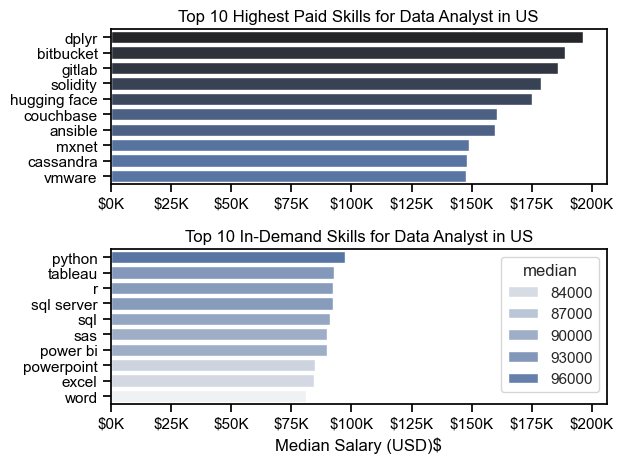

In [37]:
fig, ax = plt.subplots(2,1)

sns.set_theme(style='ticks')

#df_top_pay[::-1].plot(kind='barh',y='median',ax=ax[0],legend=False)
sns.barplot(data=df_top_pay,x='median',y=df_top_pay.index,ax=ax[0],hue='median',palette='dark:b_r')
ax[0].legend().remove()
ax[0].set_ylabel('')
ax[0].set_xlabel('')
ax[0].set_title('Top 10 Highest Paid Skills for Data Analyst in US')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,pos:f'${int(x/1000)}K'))


#df_top_skill[::-1].plot(kind='barh',y='median',ax=ax[1],legend=False)
sns.barplot(data=df_top_skill,x='median',y=df_top_skill.index,ax=ax[1],hue='median',palette='light:b')
ax[1].set_ylabel('')
ax[1].set_xlabel('Median Salary (USD)$')
ax[1].set_title('Top 10 In-Demand Skills for Data Analyst in US')
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,pos:f'${int(x/1000)}K'))
ax[1].set_xlim(ax[0].get_xlim())

fig.tight_layout()

**Example 2**

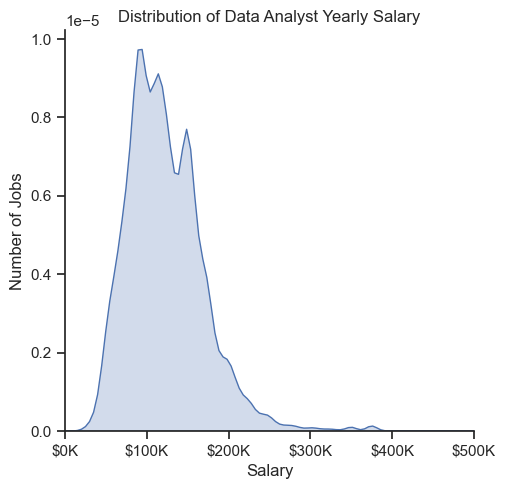

In [55]:
sns.displot(data=df['salary_year_avg'],kind='kde',fill=True)
plt.title('Distribution of Data Analyst Yearly Salary')
plt.xlabel('Salary')
plt.ylabel('Number of Jobs')
plt.xlim(0,500000)
ax= plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,pos:f'${int(x/1000)}K'))



**Example 3**

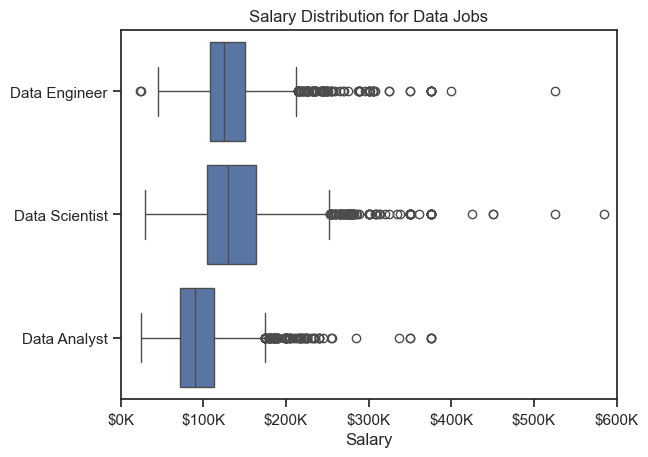

In [71]:
job_titles=['Data Analyst','Data Engineer','Data Scientist']
job_list=[]
df_USA =df[(df['job_title_short'].isin(job_titles))& (df['job_country']=='United States')].copy()
df_USA=df_USA.dropna(subset='salary_year_avg')
job_list= [df_USA[df_USA['job_title_short']==job_title]['salary_year_avg'] for job_title in job_titles]


#plt.boxplot(job_list,tick_labels=job_titles,vert=False)
sns.boxplot(data=df_USA,x='salary_year_avg',y='job_title_short')
plt.xlim(0,600000)
plt.title('Salary Distribution for Data Jobs')
plt.xlabel('Salary')
plt.ylabel('')
ax=plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,pos :f'${int(x/1000)}K'))
plt.show()